# Análisis de Productividad PDE — Publicaciones WoS
**Filtro:** Tributa PDE · WoS · Article / Review · Año configurable  
**Clasificación:** Claustro + Núcleo (exactos)  
**Scope:** 7 programas definidos por código — 93 registros / 81 académicos únicos  
**Conteo:** una publicación por RUT, independiente de cuántos programas tenga el académico  
**v6** — scope acotado a programas específicos por código

In [1]:
# ================================================================
# CONFIGURACIÓN — editar aquí antes de ejecutar
# ================================================================
ANIO_ANALISIS     = 2025
CLASIFICACIONES   = ['CLAUSTRO', 'NUCLEO', 'NÚCLEO']   # exactos
FUENTES_VALIDAS   = ['WOS', 'WEB OF SCIENCE']
TIPOS_DOC_VALIDOS = ['ARTICLE', 'REVIEW']

# Códigos de los 7 programas que forman el scope del análisis
# Agregar o quitar códigos según corresponda
CODIGOS_PROGRAMA  = [6163, 6436, 6556, 6566, 6706, 6806, 6883]

ARCHIVO_ACADEMICOS = 'LISTADO_ACADEMICOS_2025_MODIFICADO.xlsx'
ARCHIVO_PDE        = 'PDE.xlsx'
ARCHIVO_SALIDA     = f'resultado_productividad_pde_{ANIO_ANALISIS}.xlsx'


In [2]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

try:
    display
except NameError:
    def display(df):
        print(df.to_string())


In [3]:
# ================================================================
# UTILIDADES
# ================================================================
def normalizar_rut(x):
    if pd.isna(x): return None
    x = str(x).strip().upper()
    x = re.sub(r'[.]', '', x)
    x = re.sub(r'\s+', '', x)
    x = re.sub(r'[^0-9K\-]', '', x)
    return x if x else None

def normalizar_texto(x):
    if pd.isna(x): return None
    x = str(x).strip().upper()
    return re.sub(r'\s+', ' ', x) or None

def buscar_columna(df, candidatas, obligatoria=True, nombre_logico='columna'):
    for c in candidatas:
        if c in df.columns:
            return c
    if obligatoria:
        raise KeyError(
            f"Columna '{nombre_logico}' no encontrada.\n"
            f"Candidatas probadas: {candidatas}\n"
            f"Columnas disponibles: {list(df.columns)}"
        )
    return None

def contiene_tipo_valido(x, tipos_validos):
    txt = normalizar_texto(x)
    if not txt: return False
    tokens = [t.strip() for t in re.split(r'[;,|/]+', txt) if t.strip()]
    return any(t in tipos_validos for t in tokens)

def qa(titulo, valor, umbral_warn=None):
    icono = '⚠️ ' if (umbral_warn is not None and valor > umbral_warn) else '✅'
    print(f'  {icono}  {titulo}: {valor}')


In [4]:
# ================================================================
# 1. CARGA DE DATOS
# ================================================================
for archivo in [ARCHIVO_ACADEMICOS, ARCHIVO_PDE]:
    if not Path(archivo).exists():
        raise FileNotFoundError(
            f"\n❌ Archivo no encontrado: '{archivo}'\n"
            f"   Carpeta actual: {Path('.').resolve()}"
        )

print('📂 Cargando archivos...')

data    = pd.read_excel(ARCHIVO_ACADEMICOS)
autores = pd.read_excel(ARCHIVO_PDE, sheet_name='06_Autores_Publicacion')
pubs    = pd.read_excel(ARCHIVO_PDE, sheet_name='05_Publicaciones_Unicas')
wos     = pd.read_excel(ARCHIVO_PDE, sheet_name='01_WoS_Base')
scopus  = pd.read_excel(ARCHIVO_PDE, sheet_name='02_Scopus_Base')

try:
    indicadores = pd.read_excel(ARCHIVO_PDE, sheet_name='09_Indicadores_Publicacion')
except Exception:
    indicadores = pd.DataFrame()
    print('  ⚠️  Hoja 09_Indicadores_Publicacion no encontrada.')

print(f'  Académicos (todas las filas) : {len(data):,}')
print(f'  Autores PDE                  : {len(autores):,}')
print(f'  Pubs únicas                  : {len(pubs):,}')
print(f'  Registros WoS                : {len(wos):,}')
print(f'  Registros Scopus             : {len(scopus):,}')
print()

col_rut_data    = buscar_columna(data, ['RUT/Pasaporte', 'RUT', 'Rut'],             nombre_logico='RUT académicos')
col_clasif      = buscar_columna(data, ['Clasificación Académico', 'Clasificacion Academico', 'Clasificación'], nombre_logico='Clasificación')
col_nombre      = buscar_columna(data, ['Nombre Académico', 'Nombre Consolidado', 'Nombre'], obligatoria=False, nombre_logico='Nombre')
col_prog        = buscar_columna(data, ['Nombre Programa', 'Programa'],              obligatoria=False, nombre_logico='Programa')
col_cod_prog    = buscar_columna(data, ['Código Programa', 'Codigo Programa'],       obligatoria=False, nombre_logico='Código Programa')
col_rut_autores = buscar_columna(autores, ['Rut', 'RUT', 'rut'],                    nombre_logico='RUT autores PDE')

print('  Columnas detectadas:')
print(f'    RUT académicos   → {col_rut_data}')
print(f'    Clasificación    → {col_clasif}')
print(f'    Nombre           → {col_nombre}')
print(f'    Programa         → {col_prog}')
print(f'    Código Programa  → {col_cod_prog}')
print(f'    RUT autores PDE  → {col_rut_autores}')


📂 Cargando archivos...
  Académicos (todas las filas) : 1,054
  Autores PDE                  : 1,701
  Pubs únicas                  : 830
  Registros WoS                : 718
  Registros Scopus             : 797

  Columnas detectadas:
    RUT académicos   → RUT/Pasaporte
    Clasificación    → Clasificación Académico
    Nombre           → Nombre Académico
    Programa         → Nombre Programa
    Código Programa  → Código Programa
    RUT autores PDE  → Rut


In [5]:
# ================================================================
# 2. VALIDACIÓN DE CALIDAD DE DATOS (QA)
# ================================================================
print('\n🔍 Control de calidad\n')

data['rut_clean']    = data[col_rut_data].apply(normalizar_rut)
autores['rut_clean'] = autores[col_rut_autores].apply(normalizar_rut)

qa('RUTs nulos en académicos',      data['rut_clean'].isna().sum(),                umbral_warn=0)
qa('RUTs nulos en autores PDE',     autores['rut_clean'].isna().sum(),             umbral_warn=0)
qa('RUTs duplicados en académicos', data['rut_clean'].dropna().duplicated().sum(), umbral_warn=0)

print()
print('  Clasificaciones en el listado completo:')
for k, v in data[col_clasif].value_counts().items():
    print(f'    {k}: {v}')

# ── Filtro 1: Clasificación Claustro/Núcleo exactos
data['clasif_norm'] = data[col_clasif].apply(normalizar_texto)
_clasifs_upper = [c.upper() for c in CLASIFICACIONES]
data_clasif = data[data['clasif_norm'].isin(_clasifs_upper)].copy()

# ── Filtro 2: Solo los 7 programas del scope
if col_cod_prog:
    data['cod_prog_num'] = pd.to_numeric(data[col_cod_prog], errors='coerce')
    academicos_filtrados = data[
        data['clasif_norm'].isin(_clasifs_upper) &
        data['cod_prog_num'].isin(CODIGOS_PROGRAMA)
    ].copy()
else:
    print('  ⚠️  No se encontró columna de Código Programa — se usa solo filtro de clasificación')
    academicos_filtrados = data_clasif.copy()

print()
qa('Registros tras filtro clasificación + programa', len(academicos_filtrados))
qa('RUTs únicos en scope',                           academicos_filtrados['rut_clean'].nunique())

if 'Publicacion_Tributa_PDE' in pubs.columns:
    n_trib = pubs['Publicacion_Tributa_PDE'].apply(normalizar_texto).isin(['SI', 'SÍ']).sum()
    qa('Publicaciones que tributan PDE (hoja 05)', n_trib)

if 'Publication_Year' in wos.columns:
    n_anio = (wos['Publication_Year'] == ANIO_ANALISIS).sum()
    qa(f'Registros WoS año {ANIO_ANALISIS}', n_anio, umbral_warn=0)



🔍 Control de calidad

  ⚠️   RUTs nulos en académicos: 94
  ⚠️   RUTs nulos en autores PDE: 207
  ⚠️   RUTs duplicados en académicos: 376

  Clasificaciones en el listado completo:
    Colaborador: 355
    Claustro: 332
    Núcleo: 172
    Visitante: 152
    Claustro UTA: 25
    Claustro ULS: 7
    Claustro PUCV: 6
    Claustro U.Chile: 5

  ✅  Registros tras filtro clasificación + programa: 93
  ✅  RUTs únicos en scope: 81
  ✅  Publicaciones que tributan PDE (hoja 05): 466
  ⚠️   Registros WoS año 2025: 671


In [6]:
# ================================================================
# 3. CONSTRUCCIÓN DEL DATASET PDE
# ================================================================
for df_tmp in [autores, pubs]:
    df_tmp.rename(columns={'DOI_Normalizado': 'DOI_Pub', 'Titulo_Normalizado': 'Titulo_Pub'},
                  inplace=True, errors='ignore')

cols_pubs = [c for c in [
    'ID_Cluster_Publicacion', 'Fuente_Principal', 'ID_Fuente_Principal',
    'DOI_Pub', 'Titulo_Pub', 'Publicacion_Tributa_PDE'
] if c in pubs.columns]

pde = autores.merge(pubs[cols_pubs].drop_duplicates(), on='ID_Cluster_Publicacion', how='left')

if 'Publicacion_Tributa_PDE' not in pde.columns:
    if not indicadores.empty and 'Publicacion_Tributa_PDE' in indicadores.columns:
        pde = pde.merge(
            indicadores[['ID_Cluster_Publicacion', 'Publicacion_Tributa_PDE']].drop_duplicates(),
            on='ID_Cluster_Publicacion', how='left'
        )
    else:
        pde['Publicacion_Tributa_PDE'] = pd.NA

col_wos_id   = buscar_columna(wos,    ['UT_WOS', 'UT'],                          obligatoria=False, nombre_logico='ID WoS')
col_wos_year = buscar_columna(wos,    ['Publication_Year', 'PY'],                 obligatoria=False, nombre_logico='Año WoS')
col_wos_type = buscar_columna(wos,    ['Document_Type', 'DT'],                    obligatoria=False, nombre_logico='Tipo WoS')
col_sc_id    = buscar_columna(scopus, ['EID'],                                    obligatoria=False, nombre_logico='ID Scopus')
col_sc_year  = buscar_columna(scopus, ['Year', 'Publication_Year'],               obligatoria=False, nombre_logico='Año Scopus')
col_sc_type  = buscar_columna(scopus, ['Document_Type', 'SubtypeDescription'],    obligatoria=False, nombre_logico='Tipo Scopus')

frames_meta = []
if col_wos_id:
    wm = wos[[c for c in [col_wos_id, col_wos_year, col_wos_type] if c]].copy()
    wm.rename(columns={col_wos_id: 'ID_Fuente_Principal', col_wos_year: 'anio_pub',
                        col_wos_type: 'tipo_documento_meta'}, inplace=True)
    wm['schema_meta'] = 'WOS'
    frames_meta.append(wm)

if col_sc_id:
    sm = scopus[[c for c in [col_sc_id, col_sc_year, col_sc_type] if c]].copy()
    sm.rename(columns={col_sc_id: 'ID_Fuente_Principal', col_sc_year: 'anio_pub',
                        col_sc_type: 'tipo_documento_meta'}, inplace=True)
    sm['schema_meta'] = 'SCOPUS'
    frames_meta.append(sm)

if frames_meta:
    meta = pd.concat(frames_meta, ignore_index=True)
    meta = meta.dropna(subset=['ID_Fuente_Principal'])
    meta['_prio'] = meta['schema_meta'].map({'WOS': 0, 'SCOPUS': 1}).fillna(9)
    meta = (meta.sort_values(['ID_Fuente_Principal', '_prio'])
                .drop_duplicates('ID_Fuente_Principal', keep='first')
                .drop(columns='_prio'))
    pde = pde.merge(meta, on='ID_Fuente_Principal', how='left')
else:
    pde['anio_pub'] = pd.NA
    pde['tipo_documento_meta'] = pd.NA
    pde['schema_meta'] = pd.NA

pde['anio_pub'] = pd.to_numeric(pde['anio_pub'], errors='coerce')


In [7]:
# ================================================================
# 4. FILTRADO (replica criterios InCites / PDE)
# ================================================================
pde['tributa_norm'] = pde['Publicacion_Tributa_PDE'].apply(normalizar_texto)

if 'Fuente_Principal' in pde.columns:
    pde['fuente_final_norm'] = pde['Fuente_Principal'].apply(normalizar_texto)
else:
    pde['fuente_final_norm'] = pd.NA

mask_vacia = pde['fuente_final_norm'].isna()
pde.loc[mask_vacia, 'fuente_final_norm'] = (
    pde.loc[mask_vacia, 'schema_meta'].apply(normalizar_texto)
)

patron_wos = r'\b(' + '|'.join(re.escape(f) for f in FUENTES_VALIDAS) + r')\b'
pde['es_wos'] = pde['fuente_final_norm'].fillna('').str.contains(patron_wos, regex=True)
pde['es_tipo_valido'] = pde['tipo_documento_meta'].apply(
    lambda x: contiene_tipo_valido(x, set(TIPOS_DOC_VALIDOS))
)

pde_filtrado = pde[
    pde['tributa_norm'].isin(['SI', 'SÍ'])
    & (pde['anio_pub'] == ANIO_ANALISIS)
    & pde['es_wos']
    & pde['es_tipo_valido']
].copy()

print(f'📊 Registros tras filtro PDE:')
print(f'   Año {ANIO_ANALISIS} | WoS | Article/Review | Tributa = Sí')
print(f'   Registros totales    : {len(pde_filtrado):,}')
print(f'   Publicaciones únicas : {pde_filtrado["ID_Cluster_Publicacion"].nunique():,}')
print(f'   Autores únicos       : {pde_filtrado["rut_clean"].nunique():,}')


📊 Registros tras filtro PDE:
   Año 2025 | WoS | Article/Review | Tributa = Sí
   Registros totales    : 905
   Publicaciones únicas : 311
   Autores únicos       : 254


C:\Users\Infer\AppData\Local\Temp\ipykernel_27424\731234454.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  pde['es_wos'] = pde['fuente_final_norm'].fillna('').str.contains(patron_wos, regex=True)


In [8]:
# ================================================================
# 5. CONTEO POR ACADÉMICO Y RESUMEN
# ================================================================
# Una publicación cuenta una sola vez por RUT
n_pub = (
    pde_filtrado
    .dropna(subset=['rut_clean', 'ID_Cluster_Publicacion'])
    .drop_duplicates(subset=['rut_clean', 'ID_Cluster_Publicacion'])
    .groupby('rut_clean', as_index=False)
    .size()
    .rename(columns={'size': 'n_pub_WoS'})
)

# Mantener todas las filas del scope (multi-programa) y unir conteo por RUT
resultado = academicos_filtrados.merge(n_pub, on='rut_clean', how='left')
resultado['n_pub_WoS']           = resultado['n_pub_WoS'].fillna(0).astype(int)
resultado['tiene_publicaciones'] = resultado['n_pub_WoS'] > 0

detalle_cols = [c for c in [
    'rut_clean', col_nombre, 'ID_Cluster_Publicacion', 'Titulo_Pub', 'DOI_Pub',
    'Fuente_Principal', 'ID_Fuente_Principal', 'schema_meta',
    'tipo_documento_meta', 'anio_pub', 'Publicacion_Tributa_PDE'
] if c and c in pde_filtrado.columns]

detalle_debug = (
    pde_filtrado[detalle_cols]
    .drop_duplicates()
    .sort_values(['rut_clean', 'anio_pub', 'ID_Cluster_Publicacion'], na_position='last')
    .copy()
)

# Resumen a nivel RUT único
resumen_rut = resultado.drop_duplicates(subset=['rut_clean'])
total    = resumen_rut['rut_clean'].nunique()
con_pub  = resumen_rut['tiene_publicaciones'].sum()
sin_pub  = total - con_pub
max_pub  = resumen_rut['n_pub_WoS'].max()
prom_pub = resumen_rut[resumen_rut['tiene_publicaciones']]['n_pub_WoS'].mean()

print(f'📋 RESUMEN — año {ANIO_ANALISIS}')
print(f'   Total académicos únicos en scope : {total}')
print(f'   Con al menos 1 pub WoS           : {con_pub}  ({con_pub/total*100:.1f}%)')
print(f'   Sin publicaciones WoS            : {sin_pub}  ({sin_pub/total*100:.1f}%)')
print(f'   Máx. publicaciones por persona   : {max_pub}')
print(f'   Promedio (solo quienes publican) : {prom_pub:.2f}')

print('\n🏆 Top 15 por productividad:')
cols_top = [c for c in [col_nombre, col_prog, 'clasif_norm', 'n_pub_WoS']
            if c and c in resumen_rut.columns]
display(
    resumen_rut[cols_top]
    .sort_values('n_pub_WoS', ascending=False)
    .head(15)
    .reset_index(drop=True)
)


📋 RESUMEN — año 2025
   Total académicos únicos en scope : 81
   Con al menos 1 pub WoS           : 36  (44.4%)
   Sin publicaciones WoS            : 45  (55.6%)
   Máx. publicaciones por persona   : 13
   Promedio (solo quienes publican) : 2.75

🏆 Top 15 por productividad:


,Nombre Académico,Nombre Programa,clasif_norm,n_pub_WoS
0,MARTIN THIEL THIEL,DOCTORADO EN BIOLOGÍA Y ECOLOGÍA APLICADA,CLAUSTRO,13
1,SARFARAZ HASHEMKHANI,DOCTORADO EN SISTEMAS DE INGENIERÍA,CLAUSTRO,8
2,JAVIER SELLANES LOPEZ,DOCTORADO EN BIOLOGÍA Y ECOLOGÍA APLICADA,CLAUSTRO,6
3,ANNA WLODARCZYK,DOCTORADO EN SISTEMAS DE INGENIERÍA,CLAUSTRO,6
4,KATHERINA BROKORDT GUZMAN,DOCTORADO EN ACUICULTURA,CLAUSTRO,6
5,FADIA TALA GONZALEZ,DOCTORADO EN BIOLOGÍA Y ECOLOGÍA APLICADA,CLAUSTRO,5
6,GIULIANO BERNAL DOSETTO,DOCTORADO EN BIOLOGÍA Y ECOLOGÍA APLICADA,CLAUSTRO,4
7,GUILLERMO LUNA JORQUERA,DOCTORADO EN BIOLOGÍA Y ECOLOGÍA APLICADA,CLAUSTRO,3
8,CARLOS GAYMER GARCIA,DOCTORADO EN BIOLOGÍA Y ECOLOGÍA APLICADA,CLAUSTRO,3
9,GONZALO ALVAREZ VERGARA,DOCTORADO EN ACUICULTURA,CLAUSTRO,3


In [9]:
# ================================================================
# 6. EXPORTAR EXCEL FORMATEADO
# ================================================================
cols_export = [c for c in [
    col_nombre, col_prog, 'clasif_norm', 'rut_clean', 'n_pub_WoS', 'tiene_publicaciones'
] if c and c in resumen_rut.columns]

df_export = resumen_rut[cols_export].sort_values('n_pub_WoS', ascending=False).copy()
df_export.columns = [c.replace('_', ' ').title() for c in df_export.columns]

with pd.ExcelWriter(ARCHIVO_SALIDA, engine='openpyxl') as writer:
    df_export.to_excel(writer, sheet_name='Resultado', index=False)
    detalle_debug.to_excel(writer, sheet_name='Detalle_Auditoria', index=False)

    wb_out = writer.book
    thin   = Side(style='thin', color='BFBFBF')
    borde  = Border(left=thin, right=thin, top=thin, bottom=thin)

    fill_header  = PatternFill('solid', fgColor='1F3864')
    fill_con_pub = PatternFill('solid', fgColor='C6EFCE')
    fill_sin_pub = PatternFill('solid', fgColor='FCE4D6')
    font_header  = Font(bold=True, color='FFFFFF', size=11)
    font_bold    = Font(bold=True)
    a_center     = Alignment(horizontal='center', vertical='center', wrap_text=True)
    a_left       = Alignment(horizontal='left',   vertical='center')

    ws = wb_out['Resultado']

    n_pub_col_idx = None
    tiene_pub_idx = None
    for idx, cell in enumerate(ws[1], 1):
        v = str(cell.value or '').lower()
        if 'n pub' in v or 'pub wos' in v: n_pub_col_idx = idx
        if 'tiene' in v:                   tiene_pub_idx = idx

    for cell in ws[1]:
        cell.fill = fill_header; cell.font = font_header
        cell.alignment = a_center; cell.border = borde

    n_filas = len(df_export)
    for row in ws.iter_rows(min_row=2, max_row=n_filas + 1):
        tiene_pub = False
        if tiene_pub_idx:
            val = str(row[tiene_pub_idx - 1].value or '').upper()
            tiene_pub = val in ('TRUE', 'VERDADERO', '1', 'SÍ', 'SI')
        fill_row = fill_con_pub if tiene_pub else fill_sin_pub
        for cell in row:
            cell.fill = fill_row; cell.border = borde
            cell.alignment = a_center if cell.column == n_pub_col_idx else a_left
        if n_pub_col_idx:
            nc = row[n_pub_col_idx - 1]
            if isinstance(nc.value, (int, float)) and nc.value > 0:
                nc.font = font_bold

    for col in ws.columns:
        max_len = max((len(str(c.value or '')) for c in col), default=10)
        ws.column_dimensions[get_column_letter(col[0].column)].width = min(max_len + 4, 45)

    lr = n_filas + 3
    ws.cell(lr,   1, f'Total académicos únicos en scope: {total}').font = font_bold
    ws.cell(lr+1, 1, f'Con publicaciones WoS {ANIO_ANALISIS}: {con_pub}').font = font_bold
    ws.freeze_panes = 'A2'

    ws2 = wb_out['Detalle_Auditoria']
    for cell in ws2[1]:
        cell.fill = PatternFill('solid', fgColor='2E4057')
        cell.font = Font(bold=True, color='FFFFFF')
        cell.alignment = a_center
    for col in ws2.columns:
        max_len = max((len(str(c.value or '')) for c in col), default=10)
        ws2.column_dimensions[get_column_letter(col[0].column)].width = min(max_len + 3, 50)
    ws2.freeze_panes = 'A2'

print(f'✅ Archivo generado: {ARCHIVO_SALIDA}')
print(f'   "Resultado"         → {total} académicos únicos')
print(f'   "Detalle_Auditoria" → {len(detalle_debug)} registros')
print()
print('   🟢 Verde  = académico con publicaciones WoS')
print('   🔴 Salmón = académico sin publicaciones WoS')


✅ Archivo generado: resultado_productividad_pde_2025.xlsx
   "Resultado"         → 81 académicos únicos
   "Detalle_Auditoria" → 587 registros

   🟢 Verde  = académico con publicaciones WoS
   🔴 Salmón = académico sin publicaciones WoS


In [10]:
df = pd.read_excel("resultado_productividad_pde_2025.xlsx")

In [11]:
df.head()

,Nombre Académico,Nombre Programa,Clasif Norm,Rut Clean,N Pub Wos,Tiene Publicaciones
0,MARTIN THIEL THIEL,DOCTORADO EN BIOLOGÍA Y ECOLOGÍA APLICADA,CLAUSTRO,14672797-2,13.0,1.0
1,SARFARAZ HASHEMKHANI,DOCTORADO EN SISTEMAS DE INGENIERÍA,CLAUSTRO,26543022-8,8.0,1.0
2,JAVIER SELLANES LOPEZ,DOCTORADO EN BIOLOGÍA Y ECOLOGÍA APLICADA,CLAUSTRO,14652109-6,6.0,1.0
3,ANNA WLODARCZYK,DOCTORADO EN SISTEMAS DE INGENIERÍA,CLAUSTRO,24864093-6,6.0,1.0
4,KATHERINA BROKORDT GUZMAN,DOCTORADO EN ACUICULTURA,CLAUSTRO,10297065-9,6.0,1.0


In [19]:
import matplotlib.pyplot as plt 
import seaborn as sns

por_programa = df.groupby(col_prog)["N Pub Wos"].sum().sort_values()
print(por_programa)

Nombre Programa
MAGÍSTER EN POLÍTICAS PÚBLICAS Y GOBERNANZA TERRITORIAL     1.0
MAGÍSTER EN DERECHO                                         2.0
MAGÍSTER EN ADMINISTRACIÓN DE NEGOCIOS                      7.0
DOCTORADO EN CIENCIAS BIOMÉDICAS                            8.0
DOCTORADO EN ACUICULTURA                                   14.0
DOCTORADO EN SISTEMAS DE INGENIERÍA                        23.0
DOCTORADO EN BIOLOGÍA Y ECOLOGÍA APLICADA                  44.0
Name: N Pub Wos, dtype: float64


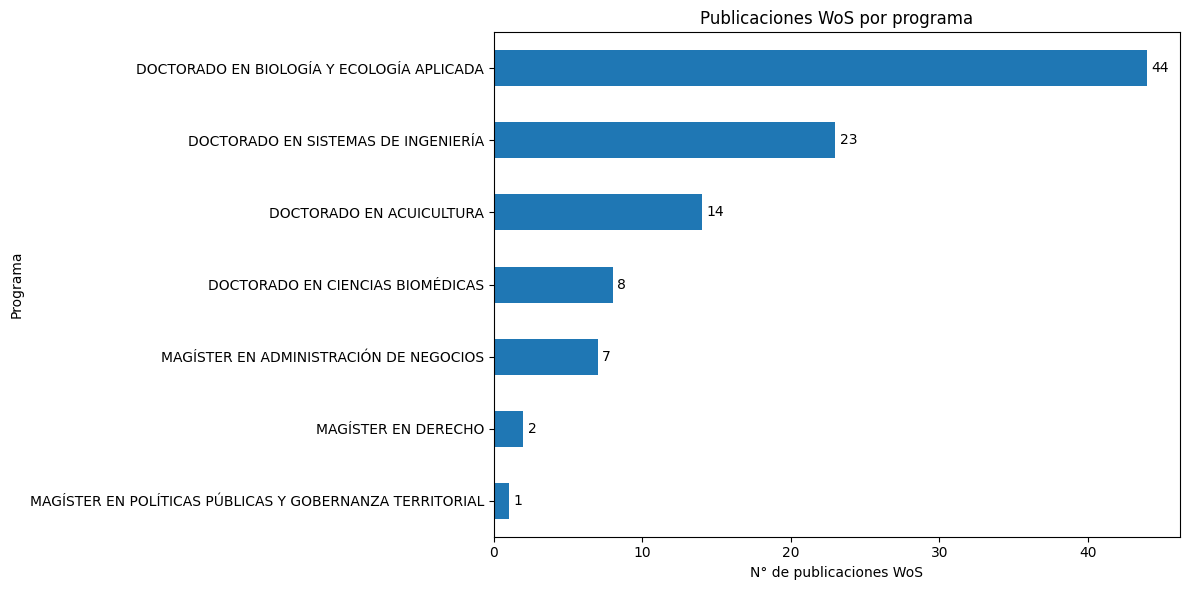

In [23]:


por_programa_ordenado = por_programa.sort_values(ascending=True)

plt.figure(figsize=(12, 6))
por_programa_ordenado.plot(kind="barh")

plt.title("Publicaciones WoS por programa")
plt.xlabel("N° de publicaciones WoS")
plt.ylabel("Programa")

for i, v in enumerate(por_programa_ordenado):
    plt.text(v + 0.3, i, str(int(v)), va="center")

plt.tight_layout()
plt.show()


In [32]:
top_publicadores = (
    df[[col_nombre, "N Pub Wos"]]
    .drop_duplicates()
    .sort_values("N Pub Wos", ascending=False)
    .head(10).sort_values("N Pub Wos", ascending=True)
)


print(top_publicadores)

            Nombre Académico  N Pub Wos
7    GUILLERMO LUNA JORQUERA        3.0
8       CARLOS GAYMER GARCIA        3.0
9    GONZALO ALVAREZ VERGARA        3.0
6    GIULIANO BERNAL DOSETTO        4.0
5        FADIA TALA GONZALEZ        5.0
4  KATHERINA BROKORDT GUZMAN        6.0
2      JAVIER SELLANES LOPEZ        6.0
3           ANNA WLODARCZYK         6.0
1      SARFARAZ HASHEMKHANI         8.0
0         MARTIN THIEL THIEL       13.0


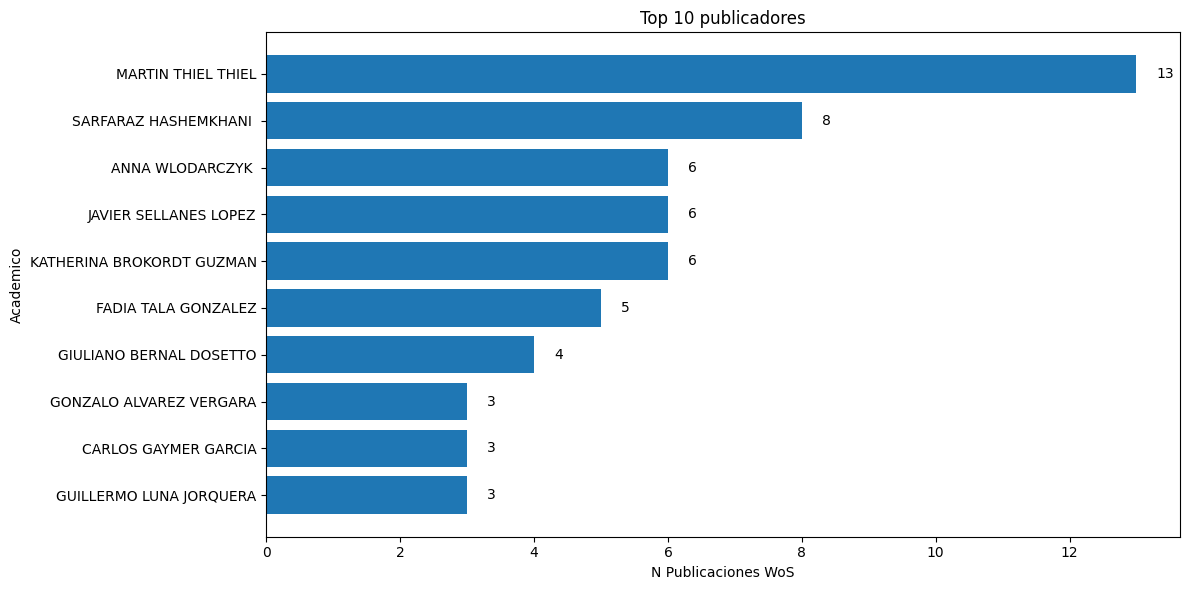

In [33]:
plt.figure(figsize=(12,6))
plt.barh(top_publicadores[col_nombre], top_publicadores["N Pub Wos"])

plt.title("Top 10 publicadores")
plt.xlabel("N Publicaciones WoS")
plt.ylabel("Academico")

for i, v in enumerate(top_publicadores["N Pub Wos"]):
    plt.text(v + 0.3, i, str(int(v)), va="center")

plt.tight_layout()
plt.show()
